<a href="https://colab.research.google.com/github/tasneem1865/Deep-Learning-Lab/blob/main/practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

23070521162 - Tasneem Sadikot

In [1]:
!pip install yfinance -q

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

In [12]:
#Download historical NASDAQ stock data
ticker = "AAPL"
data = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)
# Use only closing price
prices = data["Close"].values.reshape(-1, 1)
print("Data downloaded successfully!")
print(data.head())

#Scale the data between 0 and 1
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.171757  24.638257  23.733998  24.627201  212818400
2015-01-05  23.490807  24.021423  23.305092  23.941830  257142000
2015-01-06  23.493011  23.751686  23.132634  23.554916  263188400
2015-01-07  23.822430  23.921919  23.590285  23.700830  160423600
2015-01-08  24.737749  24.795233  24.032472  24.149651  237458000


In [13]:
# Prepare sequential data
# Use previous 60 days to predict the next day
X = []
y = []

for i in range(60, len(scaled_prices)):
    X.append(scaled_prices[i-60:i])
    y.append(scaled_prices[i])
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split data into training and testing
split = int(0.8 * len(X))
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

X shape: (2456, 60, 1)
y shape: (2456, 1)
Training data: (1964, 60, 1)
Testing data: (492, 60, 1)


In [14]:
# Build LSTM model
model = Sequential([
    Input(shape=(60, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(25),
    Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)
# Make predictions
predicted = model.predict(X_test)

# Convert values back to actual stock prices
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y_test)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0070 - val_loss: 9.0139e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 2.0376e-04 - val_loss: 9.9690e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.8979e-04 - val_loss: 8.7791e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 1.8610e-04 - val_loss: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.7818e-04 - val_loss: 7.0993e-04
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 2.0436e-04 - val_loss: 0.0010
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.9595e-04 - val_loss: 0.0014
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 1.8021e-04 - val_loss: 7.8946e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.6834e-04 - val_loss: 6.8303e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.5074e-04 - val_loss: 9.1937e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.5178e-04 - val_loss: 6

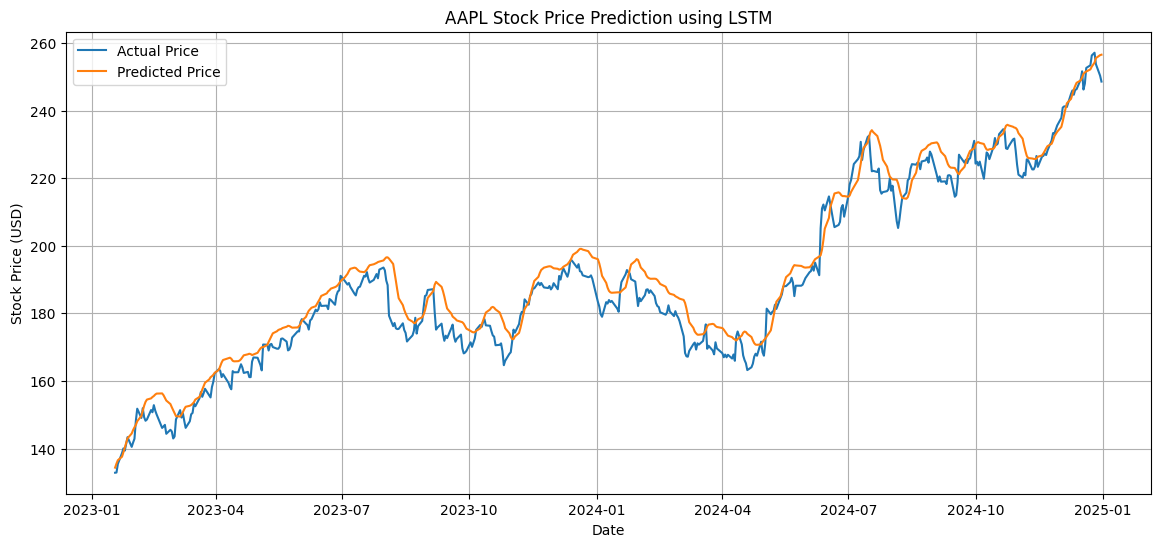

In [16]:
# Visualize Actual vs Predicted prices
test_dates = data.index[60 + split:]
plt.figure(figsize=(14, 6))
plt.plot(
    test_dates,
    actual,
    label="Actual Price"
)
plt.plot(
    test_dates,
    predicted,
    label="Predicted Price"
)
plt.title("AAPL Stock Price Prediction using LSTM")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.show()